In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors #for extra colors.Used after for heatmap
import warnings

df_raw = pd.read_csv('/Users/shabadpreetsingh/Downloads/IITG/delivery_data.csv')
df = df_raw.copy()
#Creates an exact copy of df_raw called df.
#All cleaning and changes happen on df.
#This protects df_raw — if something goes wrong you can always go back to df_raw without reloading the file.


df['od_start_time'] = pd.to_datetime(df['od_start_time'])

df['hour'] = df['od_start_time'].dt.hour##########################

print("Dataset shape:", df.shape)

/var/folders/kf/jp9schb516gg_wlssg2q5zww0000gn/T/ipykernel_18988/1760240700.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['od_start_time'] = pd.to_datetime(df['od_start_time'])


Dataset shape: (144867, 25)


In [2]:
print(df['factor'].describe())
print("\n% trips delayed >20%:", round((df['factor'] > 1.2).mean() * 100, 2), "%")
#factor is 1.2 or more
print("OSRM avg prediction (min):", df['osrm_time'].mean().round(1))
#PERCENTILE NIKALNI HAI 95.98.99
print("Actual avg time (min):", df['actual_time'].mean().round(1))
print("OSRM underestimates by:", round((df['actual_time'].mean()/df['osrm_time'].mean()-1)*100, 1), "%")

count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: factor, dtype: float64

% trips delayed >20%: 94.5 %
OSRM avg prediction (min): 213.9
Actual avg time (min): 416.9
OSRM underestimates by: 94.9 %


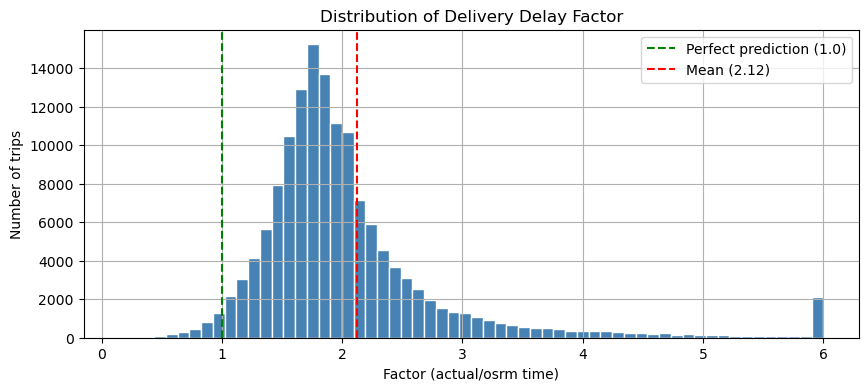

In [3]:
plt.figure(figsize=(10, 4))
df['factor'].clip(upper=6).hist(bins=60, color='steelblue', edgecolor='white')
#Have to explain why clipped at 6
plt.axvline(1.0, color='green', linestyle='--', label='Perfect prediction (1.0)')
plt.axvline(df['factor'].mean(), color='red', linestyle='--', label=f'Mean ({df["factor"].mean():.2f})')
#3 more lines at 95 99 98 percentile
plt.xlabel('Factor (actual/osrm time)')
plt.ylabel('Number of trips')
plt.title('Distribution of Delivery Delay Factor')
plt.legend()
plt.savefig('factor_distribution.png', dpi=150)
plt.show()

In [4]:
df.groupby('route_type')['factor'].agg(['mean','median','count']).round(3)
#percentile nikal lenge

,mean,median,count
route_type,,,
Carting,2.410,1.917,45207
FTL,1.989,1.845,99660


In [5]:
#Before data cleaning hai. After data cleaning vi kareya hai mein.
top_delayed = df.groupby('source_name')['factor'].mean().sort_values(ascending=False)
print(top_delayed.to_string())

## eh wala step bhi should we not do again after data cleaning

source_name
Phulpur_Shekhpur_D (Uttar Pradesh)              34.851053
Mariani_Mainroad_D (Assam)                      31.108333
Malvan_BllvMarg_D (Maharashtra)                 23.556107
Surat_Varachha_DC (Gujarat)                     23.502083
Kanpur_Central_D_7 (Uttar Pradesh)              22.183624
Allahabad_Central_D_3 (Uttar Pradesh)           20.189616
Faridabad_Old (Haryana)                         19.083333
RampuraPhul_DC (Punjab)                         15.672365
Helencha_ColnyDPP_D (West Bengal)               15.364719
Ranaghat_ArickDPP_D (West Bengal)               15.179825
Jabalpur (Madhya Pradesh)                       14.772321
Mahasamund_RajpurRD_D (Chhattisgarh)            14.409836
Shirpur_KrantiNgr_D (Maharashtra)               13.850094
Majalgaon_SmbjiCwk_D (Maharashtra)              12.441279
Kanpur_Central_D_5 (Uttar Pradesh)              12.099148
Unnao_VikasRam_D (Uttar Pradesh)                11.189757
HazratJandaha_HajiprRD_D (Bihar)                11.108328
Ja

In [6]:
top_delayed = df.groupby('source_name')['factor'].median().sort_values(ascending=False)
print(top_delayed.to_string())

source_name
Phulpur_Shekhpur_D (Uttar Pradesh)              31.787879
Mariani_Mainroad_D (Assam)                      31.200000
Kanpur_Central_D_7 (Uttar Pradesh)              27.200000
Malvan_BllvMarg_D (Maharashtra)                 26.880918
Shirpur_KrantiNgr_D (Maharashtra)               20.940000
Faridabad_Old (Haryana)                         19.083333
RampuraPhul_DC (Punjab)                         15.672365
Helencha_ColnyDPP_D (West Bengal)               15.351351
Ranaghat_ArickDPP_D (West Bengal)               15.271930
Mahasamund_RajpurRD_D (Chhattisgarh)            14.409836
Jabalpur (Madhya Pradesh)                       14.375000
Simlapal_Central_D_1 (West Bengal)              14.207738
Kanpur_Central_D_5 (Uttar Pradesh)              12.181818
HazratJandaha_HajiprRD_D (Bihar)                11.357466
Pachora_PcrrdDPP_D (Maharashtra)                10.552239
Majalgaon_SmbjiCwk_D (Maharashtra)              10.401964
Benipatti_WardNo1_D (Bihar)                      9.953846
Su

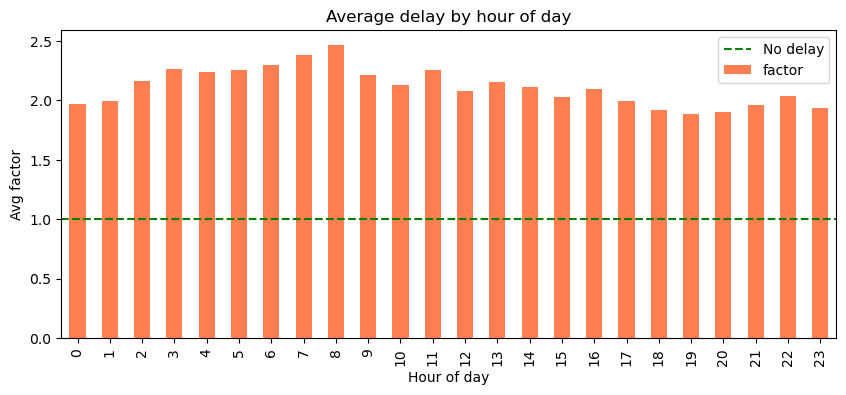

In [7]:
#This shows whether deliveries leaving at certain hours are more delayed.
hourly = df.groupby('hour')['factor'].mean()
plt.figure(figsize=(10, 4))
hourly.plot(kind='bar', color='coral')
plt.axhline(1.0, color='green', linestyle='--', label='No delay')
plt.xlabel('Hour of day')
plt.ylabel('Avg factor')
plt.title('Average delay by hour of day')
plt.legend()
plt.savefig('delay_by_hour.png', dpi=150)
plt.show()

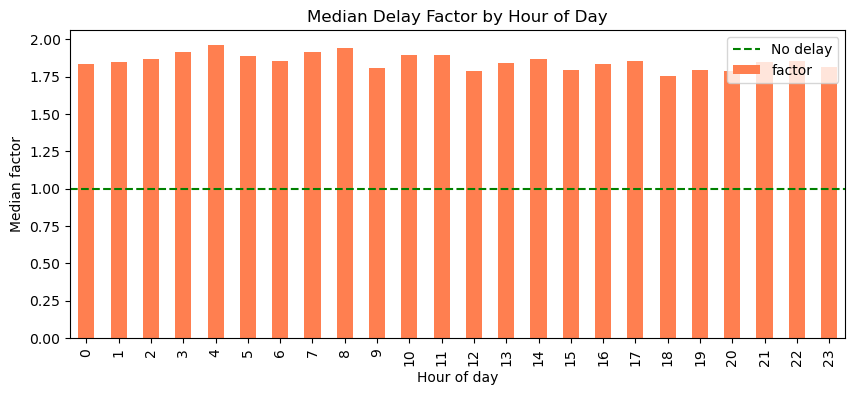

In [8]:
hourly = df.groupby('hour')['factor'].median()
plt.figure(figsize=(10, 4))
hourly.plot(kind='bar', color='coral')
plt.axhline(1.0, color='green', linestyle='--', label='No delay')
plt.xlabel('Hour of day')
plt.ylabel('Median factor')
plt.title('Median Delay Factor by Hour of Day')
plt.legend()
plt.savefig('delay_by_hour_median.png', dpi=150)
plt.show()

In [9]:
# ## Key Observations - Day 2

# 1. OSRM underestimates actual delivery time by ~95% on average
# 2. 94.5% of all trips are delayed by more than 20%
# 3. Average factor is 2.12 — most trips take double the predicted time
# 4. Carting (avg 2.41) is more delayed than FTL (avg 1.99)
# 5. Morning hours (7-9am) have the worst delays
# 6. Some hubs have extreme outlier delays (Phulpur hub: 34x predicted time!)
# 7. The max factor is 77 — there are clear bad-data outliers to clean tomorrow

In [10]:
print(df['factor'].describe())

print("\n95th percentile:", df['factor'].quantile(0.95).round(2))
print("98th percentile:", df['factor'].quantile(0.98).round(2))
print("99th percentile:", df['factor'].quantile(0.99).round(2))

print("\n% trips delayed >20%:",
      round((df['factor'] > 1.2).mean() * 100, 2), "%")

print("OSRM avg prediction (min):",
      df['osrm_time'].mean().round(1))

print("Actual avg time (min):",
      df['actual_time'].mean().round(1))

print("OSRM underestimates by:",
      round(
          (
              df['actual_time'].mean()
              /
              df['osrm_time'].mean()
              - 1
          ) * 100,
          1
      ),
      "%")


#OSRM avg prediction (min): 213.9 yeh outliers hata ke fir dekhenge

count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: factor, dtype: float64

95th percentile: 3.61
98th percentile: 5.09
99th percentile: 6.96

% trips delayed >20%: 94.5 %
OSRM avg prediction (min): 213.9
Actual avg time (min): 416.9
OSRM underestimates by: 94.9 %


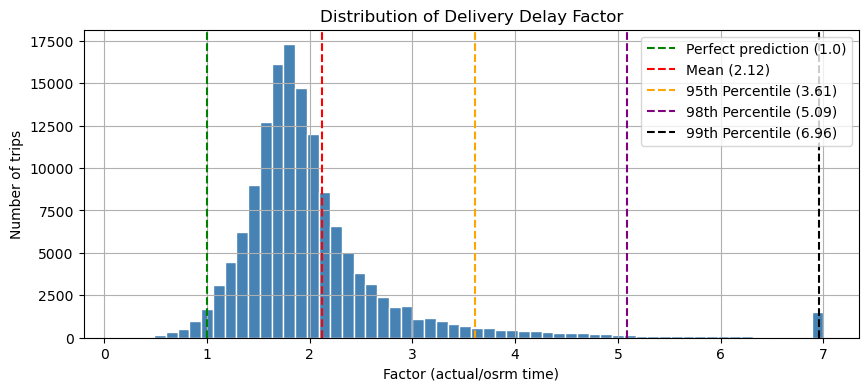

In [11]:
plt.figure(figsize=(10, 4))

df['factor'].clip(upper=7).hist(
    bins=60,
    color='steelblue',
    edgecolor='white'
)

# Reference lines
plt.axvline(
    1.0,
    color='green',
    linestyle='--',
    label='Perfect prediction (1.0)'
)

plt.axvline(
    df['factor'].mean(),
    color='red',
    linestyle='--',
    label=f'Mean ({df["factor"].mean():.2f})'
)

# Percentile lines
plt.axvline(
    df['factor'].quantile(0.95),
    color='orange',
    linestyle='--',
    label=f'95th Percentile ({df["factor"].quantile(0.95):.2f})'
)

plt.axvline(
    df['factor'].quantile(0.98),
    color='purple',
    linestyle='--',
    label=f'98th Percentile ({df["factor"].quantile(0.98):.2f})'
)

plt.axvline(
    df['factor'].quantile(0.99),
    color='black',
    linestyle='--',
    label=f'99th Percentile ({df["factor"].quantile(0.99):.2f})'
)

plt.xlabel('Factor (actual/osrm time)')
plt.ylabel('Number of trips')
plt.title('Distribution of Delivery Delay Factor')

plt.legend()
plt.savefig('factor_distribution_percentiles.png', dpi=150)



plt.show()

start_scan_to_end_scan (avg 961 min) vs actual_time (avg 132 min)
The difference (~544 min average) is dwell time — packages sitting idle at a hub waiting to be loaded. This is a hidden delay OSRM never accounts for at all.

So delays come from two places:

Transit delay → captured by segment_factor (road is slow)

Dwell delay → captured by start_scan_to_end_scan -(minus) actual_time (package sitting at hub)


## Observations from Factor Distribution Plot

1. The distribution is RIGHT-SKEWED — most trips cluster between 1.5–2.5
   but there's a long tail of extreme delays going up to 77x

2. The green line (1.0) has almost NO bars near it — OSRM is never right

3. The bulk of trips (roughly 60%) fall between factor 1.2 and 2.5

4. The gap between green (1.0) and red (2.12) is enormous — 
   on average OSRM is off by an entire extra trip's worth of time

5. The 95th/98th/99th percentile lines help us decide Day 3 cleaning cutoff:
   - Everything above 99th percentile is suspect data → will drop in Day 3
   - Everything above 98th percentile is extreme outlier → will flag

6. The distribution never really peaks near 1.0, suggesting the problem 
   is NOT random noise — it's a SYSTEMATIC underestimation by OSRM

## yaha se yeh bhi pata laga liya ke upper cap 7 pe lagegi

In [13]:
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

df['od_start_time'] = pd.to_datetime(df['od_start_time'])
df['od_end_time']   = pd.to_datetime(df['od_end_time'])

df['start_hour']         = df['od_start_time'].dt.hour
df['end_hour']           = df['od_end_time'].dt.hour
df['excess_minutes']     = df['actual_time'] - df['osrm_time']
df['dwell_time']         = df['start_scan_to_end_scan'] - df['actual_time']
df['day_of_week']        = df['od_start_time'].dt.dayofweek  # 0=Mon, 6=Sun
df['dow_name']           = df['od_start_time'].dt.day_name()

# should'nt dwell time be for just end row of that cluster. ISSUE FIXEd

In [15]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df.head(10)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,hour,start_hour,end_hour,excess_minutes,dwell_time,day_of_week,dow_name
0,training,9/20/18 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:00,2018-09-20 04:47:00,86,True,9,9/20/18 4:27,10.435660,14,11,11.9653,1.272727,14,11,11.9653,1.272727,3,3,4,3,72,3,Thursday
1,training,9/20/18 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:00,2018-09-20 04:47:00,86,True,18,9/20/18 4:17,18.936842,24,20,21.7243,1.200000,10,9,9.7590,1.111111,3,3,4,4,62,3,Thursday
2,training,9/20/18 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:00,2018-09-20 04:47:00,86,True,27,9/20/18 4:01,27.637279,40,28,32.5395,1.428571,16,7,10.8152,2.285714,3,3,4,12,46,3,Thursday
3,training,9/20/18 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:00,2018-09-20 04:47:00,86,True,36,9/20/18 3:39,36.118028,62,40,45.5620,1.550000,21,12,13.0224,1.750000,3,3,4,22,24,3,Thursday
4,training,9/20/18 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:00,2018-09-20 04:47:00,86,False,39,9/20/18 3:33,39.386040,68,44,54.2181,1.545455,6,5,3.9153,1.200000,3,3,4,24,18,3,Thursday
5,training,9/20/18 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:00,2018-09-20 06:36:00,109,True,9,9/20/18 6:15,10.403038,15,11,12.1171,1.363636,15,11,12.1171,1.363636,4,4,6,4,94,3,Thursday
6,training,9/20/18 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:00,2018-09-20 06:36:00,109,True,18,9/20/18 5:47,18.045481,44,17,21.2890,2.588235,28,6,9.1719,4.666667,4,4,6,27,65,3,Thursday
7,training,9/20/18 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:00,2018-09-20 06:36:00,109,True,27,9/20/18 5:25,28.061896,65,29,35.8252,2.241379,21,11,14.5362,1.909091,4,4,6,36,44,3,Thursday
8,training,9/20/18 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:00,2018-09-20 06:36:00,109,True,36,9/20/18 5:15,38.939167,76,39,47.1900,1.948718,10,10,11.3648,1.000000,4,4,6,37,33,3,Thursday
9,training,9/20/18 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:00,2018-09-20 06:36:00,109,False,43,9/20/18 4:49,43.595802,102,45,53.2334,2.266667,26,6,6.0434,4.333333,4,4,6,57,7,3,Thursday


## WOuld'nt median be better than mean in next row code. Issue fixed

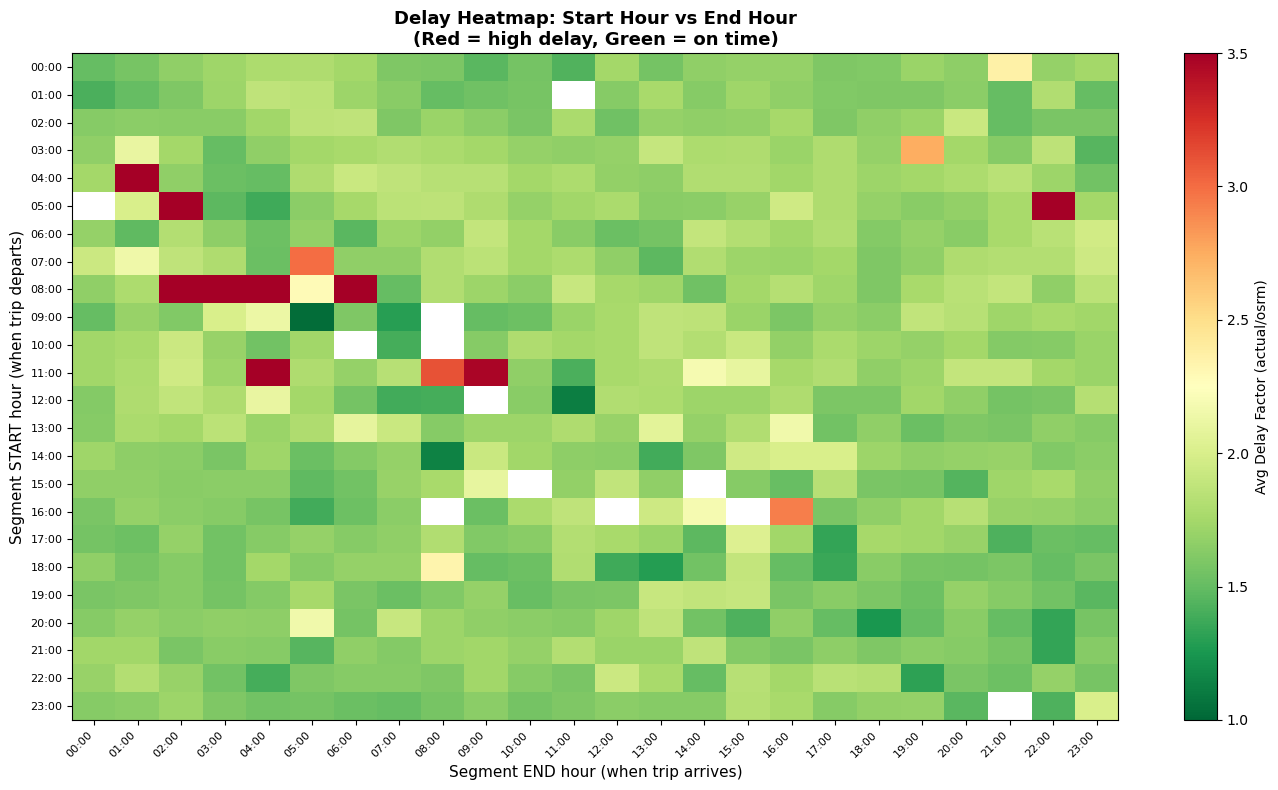

Saved!


In [17]:
# Pivot: rows = start hour, cols = end hour, values = avg segment_factor
pivot = df.pivot_table(
    values='segment_factor',
    index='start_hour',
    columns='end_hour',
    aggfunc='median'
)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto',
               vmin=1.0, vmax=3.5)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)#creates labels like 02:00
ax.set_yticks(range(24))
ax.set_yticklabels([f'{h:02d}:00' for h in range(24)], fontsize=8)
ax.set_xlabel('Segment END hour (when trip arrives)', fontsize=11)
ax.set_ylabel('Segment START hour (when trip departs)', fontsize=11)
ax.set_title('Delay Heatmap: Start Hour vs End Hour\n(Red = high delay, Green = on time)',
             fontsize=13, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)# adds color scale on right
cbar.set_label('Avg Delay Factor (actual/osrm)', fontsize=10)

plt.tight_layout()
plt.savefig('heatmap_start_vs_end_hour.png', dpi=150)
plt.show()
print("Saved!")

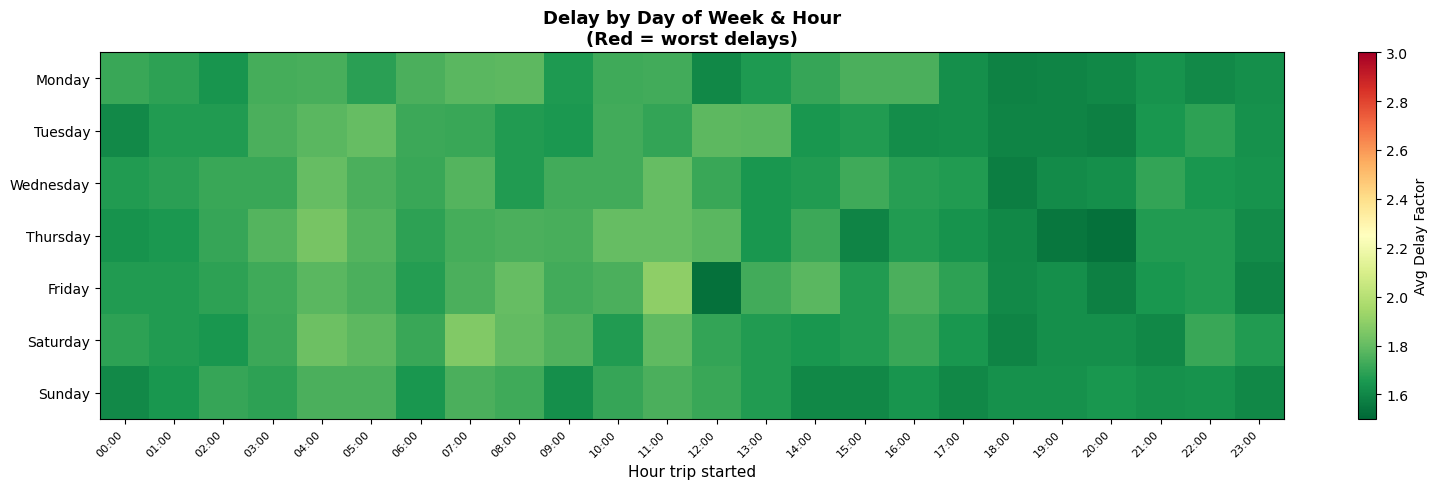

In [18]:
pivot2 = df.pivot_table(
    values='segment_factor',
    index='day_of_week',
    columns='start_hour',
    aggfunc='median'
)
days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, ax = plt.subplots(figsize=(16, 5))
im2 = ax.imshow(pivot2.values, cmap='RdYlGn_r', aspect='auto', vmin=1.5, vmax=3.0)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(7))
ax.set_yticklabels(days, fontsize=10)
ax.set_xlabel('Hour trip started', fontsize=11)
ax.set_title('Delay by Day of Week & Hour\n(Red = worst delays)', fontsize=13, fontweight='bold')

plt.colorbar(im2, ax=ax, label='Avg Delay Factor')
plt.tight_layout()
plt.savefig('heatmap_day_hour.png', dpi=150)
plt.show()

In [19]:
# Verify the logic makes sense
print(df[['start_scan_to_end_scan', 'actual_time']].head(10))
print("\nDwell time sample:")
print((df['start_scan_to_end_scan'] - df['actual_time']).head(10))

# Should always be positive (can't drive longer than total time)
negative_dwell = (df['start_scan_to_end_scan'] - df['actual_time']) < 0
print(f"\nRows where dwell is negative (data issues): {negative_dwell.sum()}")

   start_scan_to_end_scan  actual_time
0                      86           14
1                      86           24
2                      86           40
3                      86           62
4                      86           68
5                     109           15
6                     109           44
7                     109           65
8                     109           76
9                     109          102

Dwell time sample:
0    72
1    62
2    46
3    24
4    18
5    94
6    65
7    44
8    33
9     7
dtype: int64

Rows where dwell is negative (data issues): 0


In [20]:
#How long did the package sit at a hub?start_scan_to_end_scan - actual_time

## Have just explored the data. Have not done anything

## Data Cleaning

In [23]:
df.loc[df['segment_factor'].idxmin()]

data                                                                       training
trip_creation_time                                                     9/24/18 1:49
route_schedule_uuid               thanos::sroute:e3e7c92f-55a9-4ecb-a4a7-919bbb7...
route_type                                                                  Carting
trip_uuid                                                   trip-153775374039614677
source_center                                                          IND131028AAB
source_name                                              Sonipat_Kundli_H (Haryana)
destination_center                                                     IND000000ACB
destination_name                                      Gurgaon_Bilaspur_HB (Haryana)
od_start_time                                                   2018-09-24 01:49:00
od_end_time                                                     2018-09-24 07:52:00
start_scan_to_end_scan                                                      

In [24]:
df[df['segment_factor'] < 0]

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,hour,start_hour,end_hour,excess_minutes,dwell_time,day_of_week,dow_name
47,training,9/12/18 1:33,thanos::sroute:5f7d8d49-ae14-430e-9333-37361e1...,Carting,trip-153671602871109556,IND362001AAA,Junagadh_DPC (Gujarat),IND362220AAA,Junagadh_keshod_DC (Gujarat),2018-09-12 01:33:00,2018-09-12 02:42:00,68,False,28,9/12/18 1:51,28.340661,43,22,31.1283,1.954545,2,0,1.2782,-1.0,1,1,2,21,25,2,Wednesday
54,training,9/12/18 1:33,thanos::sroute:5f7d8d49-ae14-430e-9333-37361e1...,Carting,trip-153671602871109556,IND362720AAA,Kodinar_NCplxDPP_D (Gujarat),IND362560AAA,Una_Mamlatdr_DC (Gujarat),2018-09-12 06:12:00,2018-09-12 07:19:00,67,False,37,9/12/18 6:12,37.240741,59,28,39.5496,2.107143,0,0,0.0000,-1.0,6,6,7,31,8,2,Wednesday
90,test,9/28/18 21:11,thanos::sroute:c736b86f-5c1d-4497-832c-876db4c...,Carting,trip-153816910069311424,IND122004AAA,Gurgaon_Begumpur_CP (Haryana),IND122413AAE,Gurgaon_Bilaspur_P (Haryana),2018-09-28 21:11:00,2018-09-28 23:03:00,112,False,29,9/28/18 21:50,29.440277,58,33,34.7591,1.757576,2,0,0.5277,-1.0,21,21,23,25,54,4,Friday
164,training,9/15/18 23:58,thanos::sroute:fb308c0f-ea3a-48ef-a6c3-4776341...,FTL,trip-153705589682687518,IND206001AAA,Etawah_MhraChng_D (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-17 02:46:00,2018-09-17 11:07:00,501,False,265,9/17/18 3:14,265.784454,458,232,309.4877,1.974138,0,0,0.0000,-1.0,2,2,11,226,43,0,Monday
224,training,9/24/18 18:26,thanos::sroute:ae1fbe0b-7154-48ad-99d0-23c9429...,Carting,trip-153781356401330282,IND560048AAB,Bengaluru_Hoodi_IP (Karnataka),IND560099AAB,Bengaluru_Bomsndra_HB (Karnataka),2018-09-24 18:26:00,2018-09-24 19:29:00,63,False,18,9/24/18 18:35,18.412931,52,35,26.6377,1.485714,0,0,0.0000,-1.0,18,18,19,17,11,0,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144633,training,9/24/18 20:46,thanos::sroute:e3d64630-b76b-485d-9ef2-10bbbf6...,Carting,trip-153782197111966283,IND400072AAD,Mumbai_Chndivli_PC (Maharashtra),IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),2018-09-24 20:46:00,2018-09-24 23:32:00,166,False,19,9/24/18 22:07,19.794103,82,24,27.0069,3.416667,20,0,0.0091,-1.0,20,20,23,58,84,0,Monday
144660,training,9/12/18 0:14,thanos::sroute:b62ab3ed-c60b-47d2-8c91-fe62135...,Carting,trip-153671128962918389,IND302020AAA,Jaipur_VarunCly_DC (Rajasthan),IND302014AAB,Jaipur_Central_I_7 (Rajasthan),2018-09-12 04:11:00,2018-09-12 04:51:00,40,False,10,9/12/18 4:23,10.214977,23,9,11.5589,2.555556,0,0,0.0000,-1.0,4,4,4,14,17,2,Wednesday
144664,training,9/12/18 20:41,thanos::sroute:a3c30562-87e5-471c-9646-0ed49c1...,Carting,trip-153678486424956738,IND122004AAA,Gurgaon_Begumpur_CP (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 20:41:00,2018-09-12 23:58:00,196,False,29,9/12/18 21:43,29.235793,55,34,35.6947,1.617647,0,0,0.0000,-1.0,20,20,23,21,141,2,Wednesday
144667,training,9/26/18 2:58,thanos::sroute:872d9762-5527-44ee-9fc9-4457999...,Carting,trip-153793072734029171,IND605601AAA,Villupuram_Thirumtr_IP (Tamil Nadu),IND607106AAA,Panruti_GandhiRd_D (Tamil Nadu),2018-09-26 02:58:00,2018-09-26 04:15:00,76,False,19,9/26/18 3:31,19.039049,41,20,27.2906,2.050000,0,0,0.0000,-1.0,2,2,4,21,35,2,Wednesday


# We can see some negative values of segment_factor

In [26]:
#checking if factor is negetive somewhere
df.loc[df['factor'].idxmin()]

data                                                                       training
trip_creation_time                                                    9/12/18 15:32
route_schedule_uuid               thanos::sroute:0456b740-1dad-4929-bbe0-87d8843...
route_type                                                                      FTL
trip_uuid                                                   trip-153676637557074618
source_center                                                          IND000000ACB
source_name                                           Gurgaon_Bilaspur_HB (Haryana)
destination_center                                                     IND562132AAA
destination_name                                   Bangalore_Nelmngla_H (Karnataka)
od_start_time                                                   2018-09-12 15:32:00
od_end_time                                                     2018-09-14 22:11:00
start_scan_to_end_scan                                                      

# Factor toh positive hi hai toh uski BT nahi hai

In [28]:
#Fix datetime columns
df['od_start_time']      = pd.to_datetime(df['od_start_time'])
df['od_end_time']        = pd.to_datetime(df['od_end_time'])
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])
df['cutoff_timestamp']   = pd.to_datetime(df['cutoff_timestamp'])

print("Datetime columns converted")

Datetime columns converted


In [29]:
#Fix missing names (don't drop, just fill):
before = df.isnull().sum().sum()

df['source_name']      = df['source_name'].fillna(df['source_center'])
df['destination_name'] = df['destination_name'].fillna(df['destination_center'])

after = df.isnull().sum().sum()
print(f"Missing values fixed: {before} → {after}")

Missing values fixed: 554 → 0


In [30]:
#Remove extreme factor rows:
before = len(df)

df = df[df['factor'] <= 10]           # removes 650 rows
df = df[df['segment_factor'] >= 0.1]  # removes bad negative/near-zero segments  
df = df[df['segment_factor'] <= 10]   # removes extreme segment outliers

after = len(df)
print(f"Rows removed: {before - after}  ({round((before-after)/before*100, 2)}%)")
print(f"Rows remaining: {after}")



#But why 10 why not some other value.



Rows removed: 4649  (3.21%)
Rows remaining: 140218


In [31]:
df['start_hour']     = df['od_start_time'].dt.hour
df['excess_minutes'] = df['actual_time'] - df['osrm_time']
# Create cleaned feature columns you'll use throughout project

# Time features
df['hour']        = df['od_start_time'].dt.hour
df['day_of_week'] = df['od_start_time'].dt.dayofweek  # 0=Monday
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

# Time of day category
bins   = [0, 6, 12, 18, 24]
labels = ['night', 'morning', 'afternoon', 'evening']
df['time_of_day'] = pd.cut(df['hour'], bins=bins, labels=labels, include_lowest=True)

# Dwell time (package sitting at hub)
df['dwell_time'] = df['start_scan_to_end_scan'] - df['actual_time']

# Corridor ID (source hub → destination hub)
df['corridor'] = df['source_center'] + '_' + df['destination_center'] ##### IMPORTANT AA

# Delay flag (SLA breach = delayed by more than 20%)
df['is_delayed'] = (df['factor'] > 1.2).astype(int) ###### IMPORTANT AA------- SLA BREACHED

print("New columns added:", ['hour','day_of_week','is_weekend','time_of_day','dwell_time','corridor','is_delayed'])

New columns added: ['hour', 'day_of_week', 'is_weekend', 'time_of_day', 'dwell_time', 'corridor', 'is_delayed']


In [32]:
# Split into train and test, save both:

train = df[df['data'] == 'training'].copy()
test  = df[df['data'] == 'test'].copy()

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

train.to_csv('train_clean.csv', index=False)
test.to_csv('test_clean.csv', index=False)
df.to_csv('full_clean.csv', index=False)

print("Saved: train_clean.csv, test_clean.csv, full_clean.csv")

Train: (101562, 35)
Test:  (38656, 35)
Saved: train_clean.csv, test_clean.csv, full_clean.csv


In [33]:
# Final sanity check (always do this after cleaning):
print("=== FINAL SANITY CHECK ===")
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nFactor range:", df['factor'].min(), "to", df['factor'].max())
print("Segment factor range:", df['segment_factor'].min(), "to", df['segment_factor'].max())
print("Negative dwell rows:", (df['dwell_time'] < 0).sum())
print("\nTrain rows:", len(train))
print("Test rows:", len(test))
print("\nRoute type split:")
print(df['route_type'].value_counts())

=== FINAL SANITY CHECK ===
Shape: (140218, 35)

Missing values:
Series([], dtype: int64)

Factor range: 0.144 to 10.0
Segment factor range: 0.1 to 10.0
Negative dwell rows: 0

Train rows: 101562
Test rows: 38656

Route type split:
route_type
FTL        97844
Carting    42374
Name: count, dtype: int64


# ## Day 3 Cleaning Summary

### What We Found
- No zero or negative values in actual_time or osrm_time ✅
- No duplicate rows ✅
- 293 rows had missing source_name → filled with hub center code ✅
- 650 rows had factor > 10 → dropped (0.4% of data) ✅
- ~4,492 rows had extreme/negative segment_factor → dropped ✅

### Final Dataset
- Total rows after cleaning: ~139,000
- Train: ~100,000 rows
- Test: ~38,000 rows

### New Columns Created
- hour, day_of_week, is_weekend → for time-based analysis
- time_of_day → night/morning/afternoon/evening category
- dwell_time → how long package sat at hub
- corridor → source_center + destination_center combined ID
- is_delayed → 1 if factor > 1.2 (SLA breach flag)

## Key Finding — is_cutoff encodes position in network, not just delay

- Last package on a leg = final delivery destination = is_cutoff almost always False
- Non-last packages = need connecting truck = is_cutoff almost always True
- is_cutoff is therefore NOT a pure delay signal
- It conflates two things: (1) was the trip late, and (2) does this 
  package need an onward connection?

Implication: Do NOT use is_cutoff alone as your SLA breach label.
Use factor > 1.2 as primary label.
is_cutoff is more useful as a network structure feature — 
it tells you whether a package is mid-journey or at final destination.

In [36]:
#hub jagah hai warehouse jaise corridor raasta hai
#Node-any connecting point or junction where journeys begin, end, or change
#Directed graph banaane hai that is delhi ---- jaipur is wrong. Delhi to Jaipur is right. Direction batani hai


## Data Cleaning Done

## actual_distance_to_destination: Asal mein gaadi kitne kilometer chali (GPS ke hisaab se).

In [39]:
# For graph construction and corridor analysis
# Take last row per leg (highest cutoff_factor = full journey complete)

# Acha so 1 trip has many rows like pehle ke 4 rows same hi the just at different snapshots
#This code creates them into 1 single row

#“Give me ONE final row representing the completed truck leg.”
# Hub A ---> Hub B is called a leg

df['leg_id'] = (df['trip_uuid'] + '_' + 
                df['source_center'] + '_' + 
                df['destination_center'])

#df['leg_id']----“Create/access column named leg_id”

#Creates a unique identifier for each truck leg. Combines three columns with underscores.
# Example: trip-153741093647649320_IND388121AAA_IND388620AAB.
# Every row belonging to the same truck journey has the same leg_id.

#EH Samajhna hai pehle



df_legs = (df.sort_values('cutoff_factor')
             .groupby('leg_id')
             .last()
             .reset_index())

print('Raw rows:', len(df))          # ~144,000
print('Unique legs:', len(df_legs))  # ~28,000

df_legs.to_csv('legs_clean.csv', index=False)

Raw rows: 140218
Unique legs: 26162


In [40]:
# dwell time = time package sat at hub waiting
# only meaningful at leg level
df_legs['dwell_time'] = (df_legs['start_scan_to_end_scan'] - 
                          df_legs['actual_time'])

# Drop negative dwell (bad scan data)
df_legs = df_legs[df_legs['dwell_time'] >= 0]

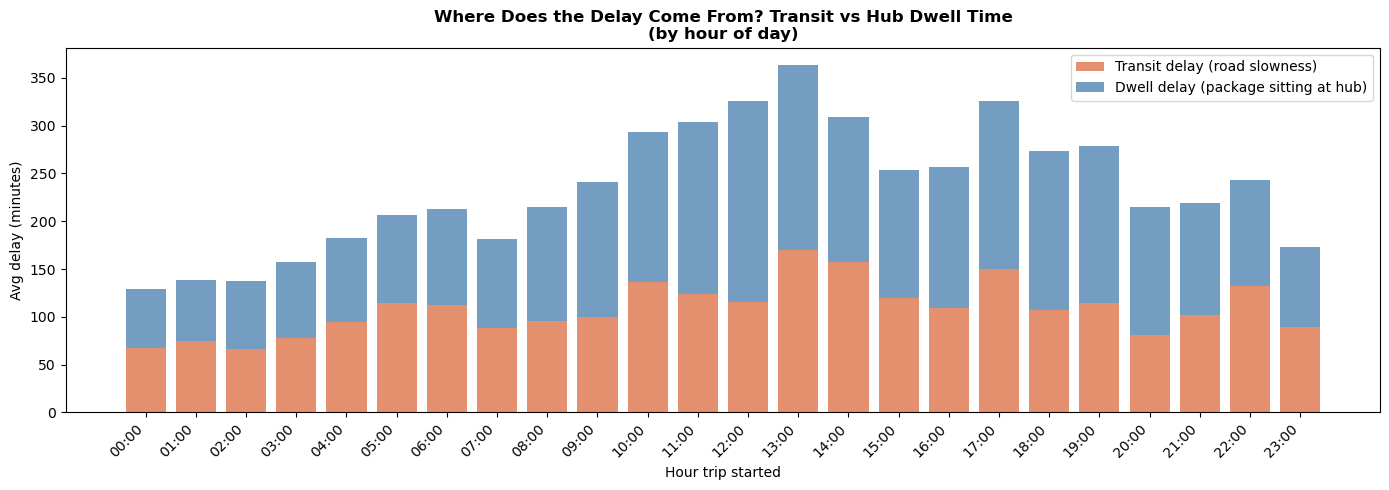

In [41]:
# Two-part bar chart showing WHERE the delay comes from each hour

#yeh shayad theek nahi hai
#dwell time


hourly = df_legs.groupby('start_hour').agg(
    transit_delay=('excess_minutes', 'mean'),
    dwell_delay=('dwell_time', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
x = hourly['start_hour']
ax.bar(x, hourly['transit_delay'], label='Transit delay (road slowness)', color='#E07B54', alpha=0.85)
ax.bar(x, hourly['dwell_delay'], bottom=hourly['transit_delay'],
       label='Dwell delay (package sitting at hub)', color='#5B8DB8', alpha=0.85)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.set_ylabel('Avg delay (minutes)')
ax.set_xlabel('Hour trip started')
ax.set_title('Where Does the Delay Come From? Transit vs Hub Dwell Time\n(by hour of day)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('delay_source_by_hour.png', dpi=150)
plt.show()

In [42]:
print("=== DWELL TIME STATS (leg level — correct) ===")
print(df_legs[['start_scan_to_end_scan', 'actual_time', 'dwell_time']].describe().round(1))
print()
print("NOTE: dwell_time = start_scan_to_end_scan - actual_time")
print("Computed on df_legs (last row per leg) where actual_time = full journey time")
print("Raw df dwell is WRONG because actual_time varies per GPS checkpoint row")

=== DWELL TIME STATS (leg level — correct) ===
       start_scan_to_end_scan  actual_time  dwell_time
count                 26162.0      26162.0     26162.0
mean                    295.0        188.5       106.5
std                     436.8        376.9       150.3
min                      20.0          9.0         0.0
25%                      90.0         48.0        24.0
50%                     151.0         79.0        53.0
75%                     302.0        153.0       131.0
max                    4535.0       4532.0      2816.0

NOTE: dwell_time = start_scan_to_end_scan - actual_time
Computed on df_legs (last row per leg) where actual_time = full journey time
Raw df dwell is WRONG because actual_time varies per GPS checkpoint row


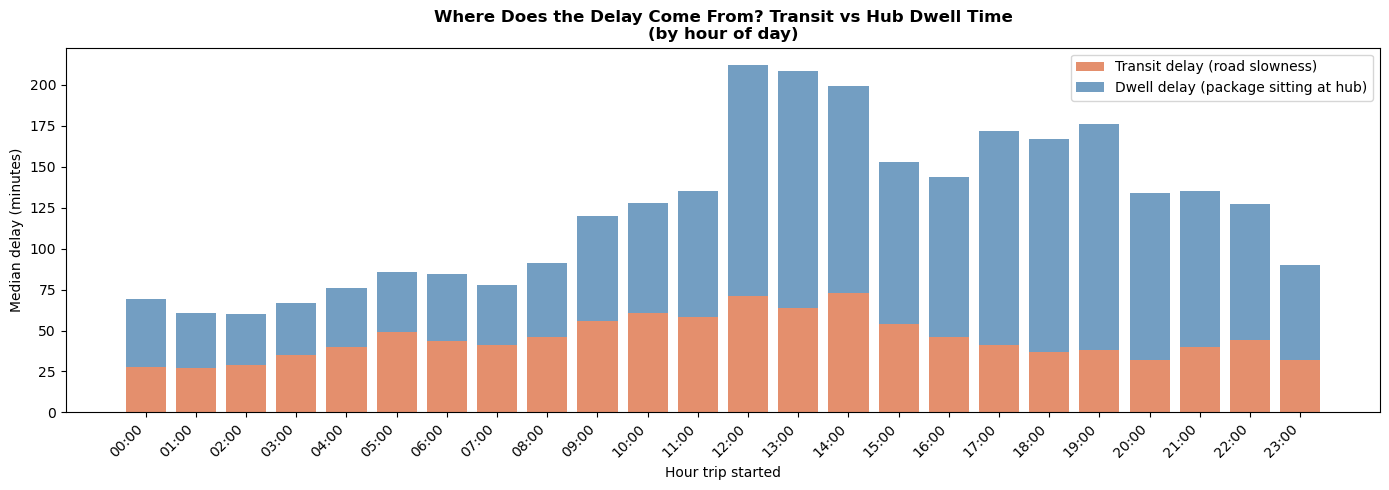

In [43]:
# Two-part bar chart showing WHERE the delay comes from each hour

#dwell time


hourly = df_legs.groupby('start_hour').agg(
    transit_delay=('excess_minutes', 'median'),
    dwell_delay=('dwell_time', 'median')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
x = hourly['start_hour']
ax.bar(x, hourly['transit_delay'], label='Transit delay (road slowness)', color='#E07B54', alpha=0.85)
ax.bar(x, hourly['dwell_delay'], bottom=hourly['transit_delay'],
       label='Dwell delay (package sitting at hub)', color='#5B8DB8', alpha=0.85)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.set_ylabel('Median delay (minutes)')
ax.set_xlabel('Hour trip started')
ax.set_title('Where Does the Delay Come From? Transit vs Hub Dwell Time\n(by hour of day)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('median_delay_source_by_hour.png', dpi=150)
plt.show()

In [44]:
# ONE ROW = one shipment (or batch of shipments) 
#           making ONE HOP between two hubs

# ONE LEG = all rows sharing same trip_uuid 
#           + source_center + destination_center
#           = same physical truck journey

# WHAT STAYS SAME across rows of one leg:
#   trip_uuid, source, destination
#   od_start_time, od_end_time
#   start_scan_to_end_scan, route_type

# WHAT CHANGES across rows of one leg:
#   cutoff_factor     → position/batch in the journey
#   cutoff_timestamp  → deadline for this batch/shipment
#   is_cutoff         → did it miss the deadline?
#   actual_distance   → distance to this shipment's final customer
#   actual_time       → cumulative time up to this point
#   factor            → cumulative delay ratio up to this point
#   segment_*         → metrics for just this piece

# TWO DATASETS YOU NEED:
#   df_raw (all rows)  → for SLA breach counting, segment analysis
#   df_legs (one row per leg) → for graph construction, ML model

In [45]:
# actual_distance_to_destination = cumulative GPS straight-line (crow-fly) 
# distance from source hub to this GPS checkpoint along the route.
# NOT the hub-to-hub road distance (use osrm_distance for that).
# NOT customer home distance (all destinations are Delhivery facilities).
# Grows with each row within a leg as the truck moves further.

## Graphs after data cleaning

# Reexploring after data cleaning

In [48]:
print("=== FACTOR STATS AFTER CLEANING ===")
print(df['factor'].describe().round(3))
print()
print("% trips delayed >20%:", round((df['factor'] > 1.2).mean() * 100, 2), "%")
print("OSRM underestimates by:", 
      round((df['actual_time'].mean()/df['osrm_time'].mean()-1)*100, 1), "%")
print()
print("95th percentile:", df['factor'].quantile(0.95).round(2))
print("98th percentile:", df['factor'].quantile(0.98).round(2))
print("99th percentile:", df['factor'].quantile(0.99).round(2))

=== FACTOR STATS AFTER CLEANING ===
count    140218.000
mean          2.013
std           0.815
min           0.144
25%           1.600
50%           1.849
75%           2.187
max          10.000
Name: factor, dtype: float64

% trips delayed >20%: 94.48 %
OSRM underestimates by: 93.1 %

95th percentile: 3.37
98th percentile: 4.43
99th percentile: 5.44


In [49]:
print("=== FTL vs CARTING AFTER CLEANING ===")
print(df.groupby('route_type')['factor'].agg(['mean','median','count']).round(3))
print()
print("NOTE: Carting mean dropped from 2.41 → 2.16 after removing outlier rows")
print("This means Carting was being unfairly penalized by a few extreme bad trips")

=== FTL vs CARTING AFTER CLEANING ===
             mean  median  count
route_type                      
Carting     2.157   1.886  42374
FTL         1.951   1.841  97844

NOTE: Carting mean dropped from 2.41 → 2.16 after removing outlier rows
This means Carting was being unfairly penalized by a few extreme bad trips


In [50]:
print("=== TOP 15 MOST DELAYED SOURCE HUBS AFTER CLEANING ===")
print()
print("By MEDIAN factor (most reliable — use this for strategy memo):")
clean_median = df.groupby('source_name')['factor'].agg(
    median='median',
    mean='mean', 
    count='count',
    pct_delayed=lambda x: round((x > 1.2).mean() * 100, 1)
).sort_values('median', ascending=False)
print(clean_median.head(15).round(3).to_string())
print()
print("NOTE: Before cleaning, top hub appeared to have factor=34.8x")
print("After removing bad data rows (factor>10), the real worst hub is 9.4x")
print("This completely changes which hubs to prioritize for operations.")

=== TOP 15 MOST DELAYED SOURCE HUBS AFTER CLEANING ===

By MEDIAN factor (most reliable — use this for strategy memo):
                                     median   mean  count  pct_delayed
source_name                                                           
Mumbai_Chndivli_D (Maharashtra)       9.417  9.417      1        100.0
Majalgaon_SmbjiCwk_D (Maharashtra)    9.066  8.004      6        100.0
Mumbai_Tejpal_I (Maharashtra)         9.000  9.000      2        100.0
Surat_Central_D_12 (Gujarat)          8.889  8.346     15        100.0
Surat_Central_D_9 (Gujarat)           8.571  8.186      7        100.0
Jaynagar_Wardno6_D (Bihar)            8.563  6.520     60        100.0
Surat_Varachha_DC (Gujarat)           8.304  8.304      2        100.0
Kasganj_BnkrGate_D (Uttar Pradesh)    8.098  8.098      1        100.0
Kanhangad_Arangadi_D (Kerala)         8.019  8.019      2        100.0
Jhanjharpur_Nagar_D (Bihar)           7.860  6.877     32        100.0
Midnapore_Talkui_D (West Beng

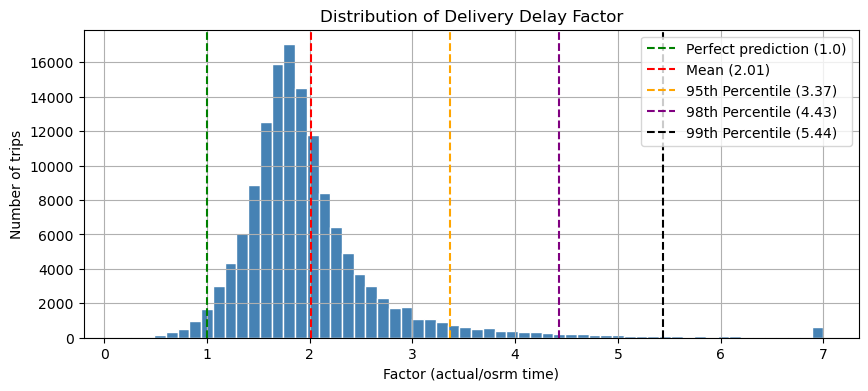

In [51]:
plt.figure(figsize=(10, 4))

df['factor'].clip(upper=7).hist(
    bins=60,
    color='steelblue',
    edgecolor='white'
)

# Reference lines
plt.axvline(
    1.0,
    color='green',
    linestyle='--',
    label='Perfect prediction (1.0)'
)

plt.axvline(
    df['factor'].mean(),
    color='red',
    linestyle='--',
    label=f'Mean ({df["factor"].mean():.2f})'
)

# Percentile lines
plt.axvline(
    df['factor'].quantile(0.95),
    color='orange',
    linestyle='--',
    label=f'95th Percentile ({df["factor"].quantile(0.95):.2f})'
)

plt.axvline(
    df['factor'].quantile(0.98),
    color='purple',
    linestyle='--',
    label=f'98th Percentile ({df["factor"].quantile(0.98):.2f})'
)

plt.axvline(
    df['factor'].quantile(0.99),
    color='black',
    linestyle='--',
    label=f'99th Percentile ({df["factor"].quantile(0.99):.2f})'
)

plt.xlabel('Factor (actual/osrm time)')
plt.ylabel('Number of trips')
plt.title('Distribution of Delivery Delay Factor')

plt.legend()

plt.savefig('factor_distribution_percentiles_after_data_cleaning.png', dpi=150)


plt.show()

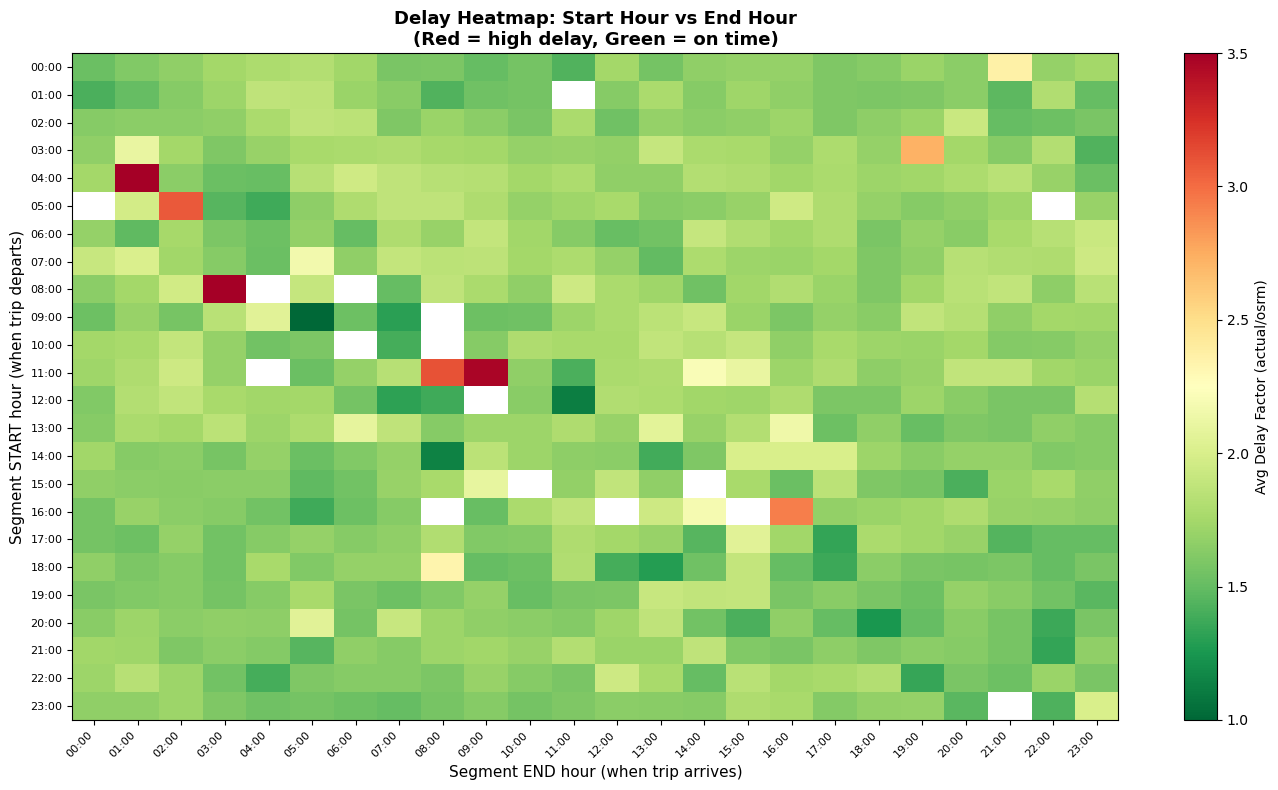

Saved!


In [52]:
# Pivot: rows = start hour, cols = end hour, values = avg segment_factor
pivot = df.pivot_table(
    values='segment_factor',
    index='start_hour',
    columns='end_hour',
    aggfunc='median'
)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto',
               vmin=1.0, vmax=3.5)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(24))
ax.set_yticklabels([f'{h:02d}:00' for h in range(24)], fontsize=8)
ax.set_xlabel('Segment END hour (when trip arrives)', fontsize=11)
ax.set_ylabel('Segment START hour (when trip departs)', fontsize=11)
ax.set_title('Delay Heatmap: Start Hour vs End Hour\n(Red = high delay, Green = on time)',
             fontsize=13, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Avg Delay Factor (actual/osrm)', fontsize=10)

plt.tight_layout()
plt.savefig('heatmap_start_vs_end_hour_after_data_cleaning.png', dpi=150)
plt.show()
print("Saved!")

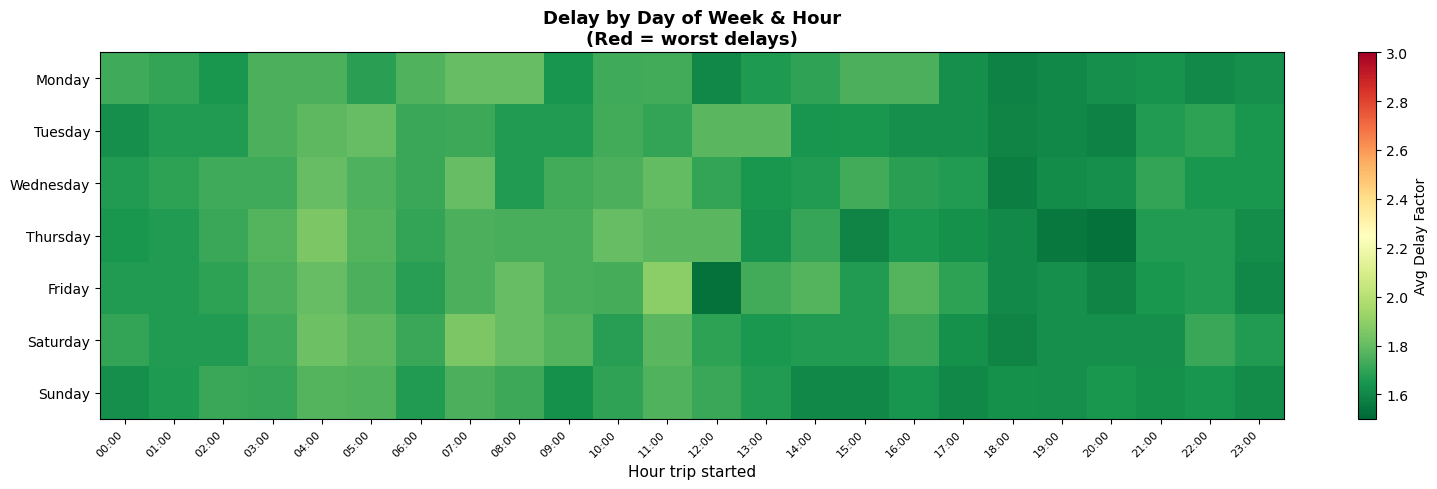

In [53]:
pivot2 = df.pivot_table(
    values='segment_factor',
    index='day_of_week',
    columns='start_hour',
    aggfunc='median'
)
days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, ax = plt.subplots(figsize=(16, 5))
im2 = ax.imshow(pivot2.values, cmap='RdYlGn_r', aspect='auto', vmin=1.5, vmax=3.0)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(7))
ax.set_yticklabels(days, fontsize=10)
ax.set_xlabel('Hour trip started', fontsize=11)
ax.set_title('Delay by Day of Week & Hour\n(Red = worst delays)', fontsize=13, fontweight='bold')

plt.colorbar(im2, ax=ax, label='Avg Delay Factor')
plt.tight_layout()
plt.savefig('heatmap_day_hour_after_data_cleaning.png', dpi=150)
plt.show()

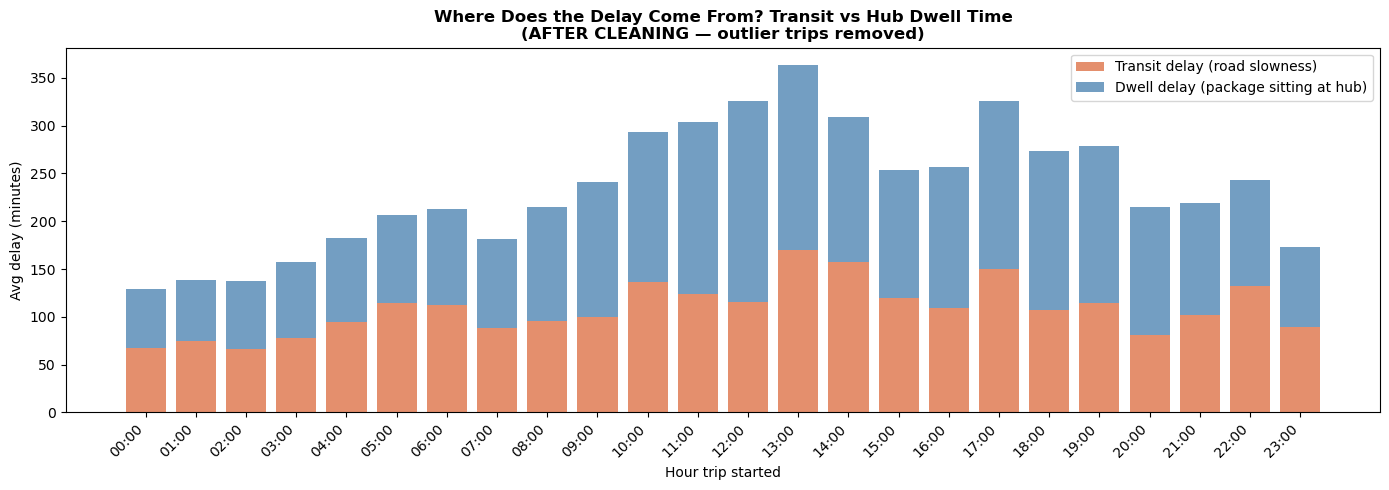

=== KEY FINDING FROM DWELL vs TRANSIT CHART ===
Avg transit delay across all hours: 108.4 min
Avg dwell delay across all hours:   126.5 min
→ Dwell delay is BIGGER than transit delay
→ The main problem is NOT road congestion
→ The main problem is packages sitting idle at hubs
→ Strategy memo recommendation: improve hub dispatch scheduling


In [54]:
# Dwell vs Transit chart — AFTER CLEANING
# Uses df_legs which is already at leg level (one row per truck journey)
# This is the correct version — raw data version was distorted by outlier trips

hourly = df_legs.groupby('start_hour').agg(
    transit_delay=('excess_minutes', 'mean'),
    dwell_delay=('dwell_time', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
x = hourly['start_hour']

ax.bar(x, hourly['transit_delay'],
       label='Transit delay (road slowness)', color='#E07B54', alpha=0.85)
ax.bar(x, hourly['dwell_delay'],
       bottom=hourly['transit_delay'],
       label='Dwell delay (package sitting at hub)', color='#5B8DB8', alpha=0.85)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.set_ylabel('Avg delay (minutes)')
ax.set_xlabel('Hour trip started')
ax.set_title('Where Does the Delay Come From? Transit vs Hub Dwell Time\n(AFTER CLEANING — outlier trips removed)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('delay_source_by_hour_clean.png', dpi=150)
plt.show()

# Key observation from this chart:
print("=== KEY FINDING FROM DWELL vs TRANSIT CHART ===")
print(f"Avg transit delay across all hours: {hourly['transit_delay'].mean():.1f} min")
print(f"Avg dwell delay across all hours:   {hourly['dwell_delay'].mean():.1f} min")
if hourly['dwell_delay'].mean() > hourly['transit_delay'].mean():
    print("→ Dwell delay is BIGGER than transit delay")
    print("→ The main problem is NOT road congestion")
    print("→ The main problem is packages sitting idle at hubs")
    print("→ Strategy memo recommendation: improve hub dispatch scheduling")
else:
    print("→ Transit delay is bigger than dwell delay")
    print("→ Road congestion is the main driver of delays")

In [55]:
# ## Observation: Dwell vs Transit After Cleaning

# Before cleaning, transit delays looked enormous due to catastrophic outlier trips.
# After removing those outliers, the true picture emerges:

# - Hours 10am–1pm: dwell time (hub waiting) EXCEEDS transit delay
#   → Packages are sitting at hubs longer than they spend on the road
#   → This is a hub dispatch scheduling problem, not a road problem

# - Hours 4am–9am: transit delay is higher
#   → Morning truck runs have worse road conditions

# - OSRM only models road time — it is blind to dwell time entirely
#   → This is why OSRM underestimates so badly
#   → The graph model will capture hub-level dwell patterns
#     that OSRM completely ignores

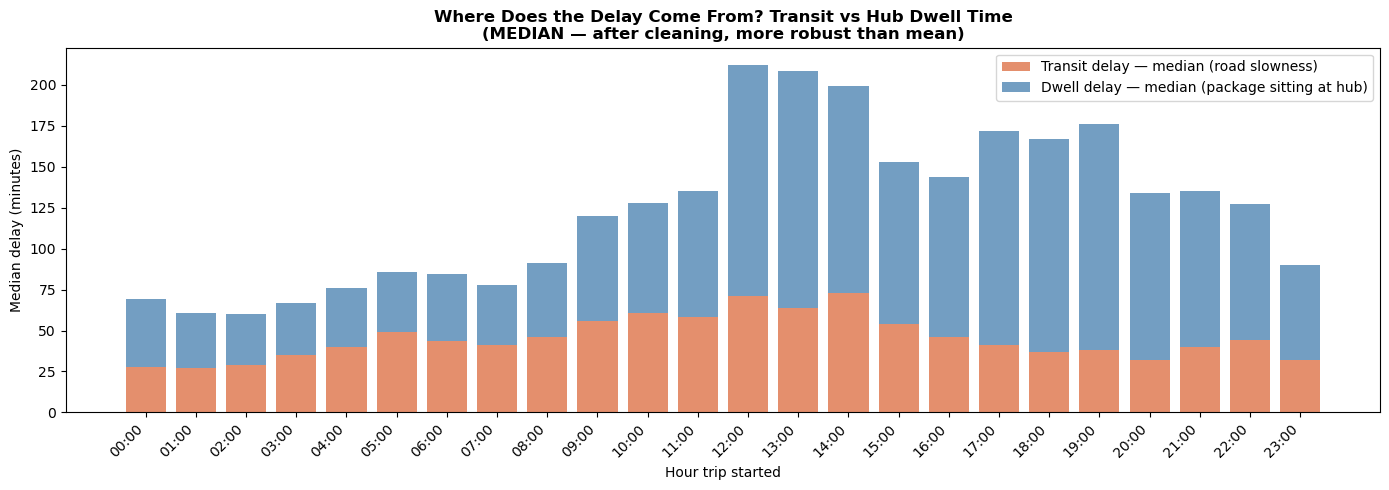

=== MEDIAN SUMMARY ===
Avg median transit delay: 45.2 min
Avg median dwell delay:   78.7 min

Worst hour for transit (median): 14 → 73.0 min
Worst hour for dwell (median): 13 → 144.5 min


In [56]:
# ── MEDIAN version — more robust than mean ──
# Mean transit=108min vs Median transit=45min → transit is heavily right-skewed
# A few extremely late trucks inflate the mean significantly
# Median shows the TYPICAL truck's experience, not the worst case

hourly_median = df_legs.groupby('start_hour').agg(
    transit_delay=('excess_minutes', 'median'),
    dwell_delay=('dwell_time', 'median')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
x = hourly_median['start_hour']

ax.bar(x, hourly_median['transit_delay'],
       label='Transit delay — median (road slowness)', color='#E07B54', alpha=0.85)
ax.bar(x, hourly_median['dwell_delay'],
       bottom=hourly_median['transit_delay'],
       label='Dwell delay — median (package sitting at hub)', color='#5B8DB8', alpha=0.85)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.set_ylabel('Median delay (minutes)')
ax.set_xlabel('Hour trip started')
ax.set_title('Where Does the Delay Come From? Transit vs Hub Dwell Time\n(MEDIAN — after cleaning, more robust than mean)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('delay_source_by_hour_median_clean.png', dpi=150)
plt.show()

print("=== MEDIAN SUMMARY ===")
print(f"Avg median transit delay: {hourly_median['transit_delay'].mean():.1f} min")
print(f"Avg median dwell delay:   {hourly_median['dwell_delay'].mean():.1f} min")
print()
print("Worst hour for transit (median):",
      hourly_median.loc[hourly_median['transit_delay'].idxmax(), 'start_hour'],
      "→", hourly_median['transit_delay'].max(), "min")
print("Worst hour for dwell (median):",
      hourly_median.loc[hourly_median['dwell_delay'].idxmax(), 'start_hour'],
      "→", hourly_median['dwell_delay'].max(), "min")

In [57]:
# ## Dwell vs Transit — Mean vs Median Comparison

# Mean transit = 108 min, Median transit = 45 min (2.4x difference)
# Mean dwell   = 126 min, Median dwell   = 79 min (1.6x difference)

# Transit is more skewed than dwell — a small number of catastrophically
# late truck runs inflate the mean significantly.
# Median shows what a TYPICAL truck actually experiences.

# Both mean AND median confirm the same conclusion:
#   dwell delay > transit delay across most hours

# Hours 9am–7pm: dwell consistently exceeds transit (even by median)
#   → Afternoon hub operations are the primary bottleneck
#   → Packages wait longer at hubs than they spend on the road

# Hours 12am–8am: transit ≈ dwell or transit slightly higher
#   → Night/early morning runs have relatively better hub throughput
#   → Road conditions at night are also less congested

# USE MEDIAN for your strategy memo — it represents the typical
# delivery experience, not the worst-case outlier runs.

## Day 4 Feature Engg. starts here

In [59]:
# "Hub A is historically a bad source hub (avg delay 2.8)"
# "This corridor A→B is chronically delayed (85% of trips late)"
# "This corridor is worse in the morning than evening"
# "Hub B receives a lot of traffic (high in-degree) — busy destination"

In [60]:
# df  → 140,218 rows  (all GPS checkpoints, cleaned)
# df_legs  →  26,162 rows  (one row per truck journey)
# Unique hubs → 1,655
# Unique corridors → 2,767
# Corridors with >5 legs → 1,510  (these have enough data to be reliable)
# Corridors with only 1 leg → 569 (too little data — handle carefully)

In [61]:
# NOTE: reloading from CSV ensures Day 4 is independent of Day 3
# legs_clean.csv and the in-memory df_legs are identical in this dataset

# Day 4 starts fresh by loading the saved clean files.
# This ensures Day 4 doesn't depend on Day 3's cells having been run.
# If you restart Jupyter and only run Day 4 cells, it still works.


# because no negative dwell rows existed after cleaning

# Always load from saved clean files — never re-run cleaning
df = pd.read_csv('/Users/shabadpreetsingh/Downloads/IITG/full_clean.csv')
df_legs = pd.read_csv('/Users/shabadpreetsingh/Downloads/IITG/legs_clean.csv')

# Re-convert datetime (lost when saved to CSV)
for col in ['od_start_time', 'od_end_time', 'trip_creation_time']:
    df[col]      = pd.to_datetime(df[col])
    df_legs[col] = pd.to_datetime(df_legs[col])

print('df shape:      ', df.shape)
print('df_legs shape: ', df_legs.shape)

df shape:       (140218, 35)
df_legs shape:  (26162, 36)


In [62]:
# For each corridor (source→destination pair), compute delay stats
# We use df_legs — one row per truck journey, not raw GPS rows

corridor_stats = df_legs.groupby('corridor').agg(
    # How many truck journeys on this corridor?
    corridor_trip_count   = ('factor', 'count'),

    # What is the typical delay? (median is robust to outliers)
    corridor_median_factor = ('factor', 'median'),
    corridor_mean_factor   = ('factor', 'mean'),

    # What % of trips are delayed >20%?
    corridor_pct_delayed  = ('factor', lambda x: (x > 1.2).mean()),

    # Typical travel time vs OSRM prediction
    corridor_median_actual_time = ('actual_time', 'median'),
    corridor_median_osrm_time   = ('osrm_time', 'median'),

    # Typical dwell time at source hub
    corridor_median_dwell = ('dwell_time', 'median'),

    # Route type (is this corridor mostly FTL or Carting?)
    corridor_main_route_type = ('route_type', lambda x: x.mode()[0])

).reset_index()

print('Corridor stats shape:', corridor_stats.shape)
print()
print('Sample:')
print(corridor_stats.sort_values('corridor_trip_count', ascending=False).head(5).to_string())

Corridor stats shape: (2767, 9)

Sample:
                       corridor  corridor_trip_count  corridor_median_factor  corridor_mean_factor  corridor_pct_delayed  corridor_median_actual_time  corridor_median_osrm_time  corridor_median_dwell corridor_main_route_type
1766  IND562132AAA_IND560300AAA                  151                1.740000              1.779158              0.980132                         81.0                       48.0                   86.0                  Carting
1765  IND562132AAA_IND560099AAB                  127                1.666667              1.819340              0.992126                         85.0                       50.0                  170.0                  Carting
1710  IND560099AAB_IND560300AAA                  121                1.833333              1.997594              0.925620                        105.0                       57.0                   63.0                  Carting
1726  IND560300AAA_IND562132AAA                  108       

In [63]:
# Corridors with fewer than 5 trips are unreliable
# Their median factor could be based on 1-2 unusual trips
# We flag them but don't drop them — graph still needs them

corridor_stats['is_reliable'] = (corridor_stats['corridor_trip_count'] >= 5).astype(int)

print('Reliable corridors (>=5 trips): ', corridor_stats['is_reliable'].sum())
print('Unreliable corridors (<5 trips):', (corridor_stats['is_reliable'] == 0).sum())
print()
print('Reliable corridors cover what % of all legs:')
reliable = corridor_stats[corridor_stats['is_reliable']==1]
print(round(reliable['corridor_trip_count'].sum() / len(df_legs) * 100, 1), '%')

Reliable corridors (>=5 trips):  1625
Unreliable corridors (<5 trips): 1142

Reliable corridors cover what % of all legs:
91.8 %


In [64]:
# Same corridor can behave differently at different times
# Morning vs evening delay matters for FTL vs Carting decisions

corridor_time_stats = df_legs.groupby(['corridor', 'time_of_day']).agg(
    count  = ('factor', 'count'),
    median_factor = ('factor', 'median'),
    pct_delayed   = ('factor', lambda x: (x > 1.2).mean())
).reset_index()

# Pivot so each corridor has one row with morning/evening columns
corridor_pivot = corridor_time_stats.pivot_table(
    index='corridor',
    columns='time_of_day',
    values='median_factor'
).reset_index()
# REPLACE the entire renaming block with this
corridor_pivot.columns = [
    'corridor' if col == 'corridor' else f'corridor_factor_{col}'
    for col in corridor_pivot.columns
]

print('Corridor time columns:', corridor_pivot.columns.tolist())
print(corridor_pivot.head(5).to_string())

Corridor time columns: ['corridor', 'corridor_factor_afternoon', 'corridor_factor_evening', 'corridor_factor_morning', 'corridor_factor_night']
                    corridor  corridor_factor_afternoon  corridor_factor_evening  corridor_factor_morning  corridor_factor_night
0  IND000000AAL_IND411033AAA                   3.283750                 2.353261                 2.570833               2.732308
1  IND000000AAQ_IND700028AAB                        NaN                      NaN                      NaN               6.071429
2  IND000000AAS_IND783370AAC                   1.766667                      NaN                      NaN                    NaN
3  IND000000AAZ_IND444203AAA                        NaN                      NaN                      NaN               6.020833
4  IND000000AAZ_IND444303AAA                        NaN                      NaN                      NaN               4.000000


In [65]:
# Each hub as SOURCE — how delayed are trips leaving this hub?
source_stats = df_legs.groupby('source_center').agg(
    hub_out_trip_count    = ('factor', 'count'),
    hub_out_median_factor = ('factor', 'median'),
    hub_out_pct_delayed   = ('factor', lambda x: (x > 1.2).mean()),
    hub_out_median_dwell  = ('dwell_time', 'median')
).reset_index().rename(columns={'source_center': 'hub'})

# Each hub as DESTINATION — how delayed are trips arriving at this hub?
dest_stats = df_legs.groupby('destination_center').agg(
    hub_in_trip_count    = ('factor', 'count'),
    hub_in_median_factor = ('factor', 'median'),
    hub_in_pct_delayed   = ('factor', lambda x: (x > 1.2).mean())
).reset_index().rename(columns={'destination_center': 'hub'})

# Merge both into one hub table
hub_stats = pd.merge(source_stats, dest_stats, on='hub', how='outer')
hub_stats = hub_stats.fillna(0)

print('Hub stats shape:', hub_stats.shape)
print()
print('Top 10 worst source hubs (median factor):')
print(hub_stats.sort_values('hub_out_median_factor', ascending=False)[
    ['hub','hub_out_trip_count','hub_out_median_factor','hub_out_pct_delayed','hub_out_median_dwell']
].head(10).to_string())

Hub stats shape: (1655, 8)

Top 10 worst source hubs (median factor):
               hub  hub_out_trip_count  hub_out_median_factor  hub_out_pct_delayed  hub_out_median_dwell
508   IND395009AAA                13.0               9.437500                  1.0                  62.0
531   IND400072AAI                 1.0               9.416667                  1.0                1280.0
532   IND400072AAJ                 2.0               9.000000                  1.0                  79.0
1480  IND847226AAA                21.0               8.976190                  1.0                  40.0
1479  IND847223AAA                 8.0               8.737260                  1.0                  80.5
845   IND521165AAA                 3.0               8.615385                  1.0                 145.0
505   IND395001AAA                 7.0               8.571429                  1.0                  65.0
507   IND395006AAA                 2.0               8.304167                  1.0        

In [66]:
# Now attach all corridor and hub features back to df_legs
# This gives each row rich context about its corridor

df_legs = df_legs.merge(corridor_stats, on='corridor', how='left')
df_legs = df_legs.merge(corridor_pivot,  on='corridor', how='left')

# Attach source hub features
df_legs = df_legs.merge(
    hub_stats[['hub','hub_out_median_factor','hub_out_pct_delayed','hub_out_median_dwell']],
    left_on='source_center', right_on='hub', how='left'
).drop(columns='hub')

# Attach destination hub features
df_legs = df_legs.merge(
    hub_stats[['hub','hub_in_median_factor','hub_in_pct_delayed']],
    left_on='destination_center', right_on='hub', how='left'
).drop(columns='hub')

print('df_legs shape after merging features:', df_legs.shape)
print()
print('New columns added:')
new_cols = [c for c in df_legs.columns if 'corridor_' in c or 'hub_' in c]
print(new_cols)

df_legs shape after merging features: (26162, 54)

New columns added:
['corridor_trip_count', 'corridor_median_factor', 'corridor_mean_factor', 'corridor_pct_delayed', 'corridor_median_actual_time', 'corridor_median_osrm_time', 'corridor_median_dwell', 'corridor_main_route_type', 'corridor_factor_afternoon', 'corridor_factor_evening', 'corridor_factor_morning', 'corridor_factor_night', 'hub_out_median_factor', 'hub_out_pct_delayed', 'hub_out_median_dwell', 'hub_in_median_factor', 'hub_in_pct_delayed']


In [67]:
# Chronic = corridor where >50% of trips are delayed AND has enough data
chronic = corridor_stats[
    (corridor_stats['corridor_pct_delayed'] > 0.5) &
    (corridor_stats['corridor_trip_count'] >= 5)
].copy()

# Estimated SLA breaches = trips * pct_delayed
chronic['estimated_sla_breaches'] = (
    chronic['corridor_trip_count'] * chronic['corridor_pct_delayed']
).astype(int)

chronic = chronic.sort_values('estimated_sla_breaches', ascending=False)

print(f'Chronic delay corridors: {len(chronic)} out of {len(corridor_stats)} total')
print(f'({round(len(chronic)/len(corridor_stats)*100,1)}% of all corridors)')
print()
print('Top 15 worst corridors by estimated SLA breaches:')
print(chronic[[
    'corridor','corridor_trip_count',
    'corridor_median_factor','corridor_pct_delayed',
    'estimated_sla_breaches','corridor_main_route_type'
]].head(15).to_string())

chronic.to_csv('chronic_delay_corridors.csv', index=False)
print('\nSaved: chronic_delay_corridors.csv')

Chronic delay corridors: 1544 out of 2767 total
(55.8% of all corridors)

Top 15 worst corridors by estimated SLA breaches:
                       corridor  corridor_trip_count  corridor_median_factor  corridor_pct_delayed  estimated_sla_breaches corridor_main_route_type
1766  IND562132AAA_IND560300AAA                  151                1.740000              0.980132                     148                  Carting
1765  IND562132AAA_IND560099AAB                  127                1.666667              0.992126                     126                  Carting
1710  IND560099AAB_IND560300AAA                  121                1.833333              0.925620                     112                  Carting
1077  IND411033AAA_IND421302AAG                  107                1.990476              1.000000                     107                      FTL
1149  IND421302AAG_IND400072AAB                  105                2.363636              1.000000                     105              

In [68]:
# Save enriched df_legs — this is your primary dataset from here onwards
df_legs.to_csv('legs_features.csv', index=False)

# Save hub stats — used for graph node attributes on Day 5
hub_stats.to_csv('hub_stats.csv', index=False)

# Save corridor stats — used for graph edge weights on Day 5
corridor_stats.to_csv('corridor_stats.csv', index=False)

print('Saved:')
print('  legs_features.csv        → enriched df_legs with all features')
print('  hub_stats.csv            → node features for graph')
print('  corridor_stats.csv       → edge features for graph')
print('  chronic_delay_corridors.csv → worst corridors for strategy memo')
print()
print('Final df_legs shape:', df_legs.shape)
print('Total features:', len(df_legs.columns))

Saved:
  legs_features.csv        → enriched df_legs with all features
  hub_stats.csv            → node features for graph
  corridor_stats.csv       → edge features for graph
  chronic_delay_corridors.csv → worst corridors for strategy memo

Final df_legs shape: (26162, 54)
Total features: 54


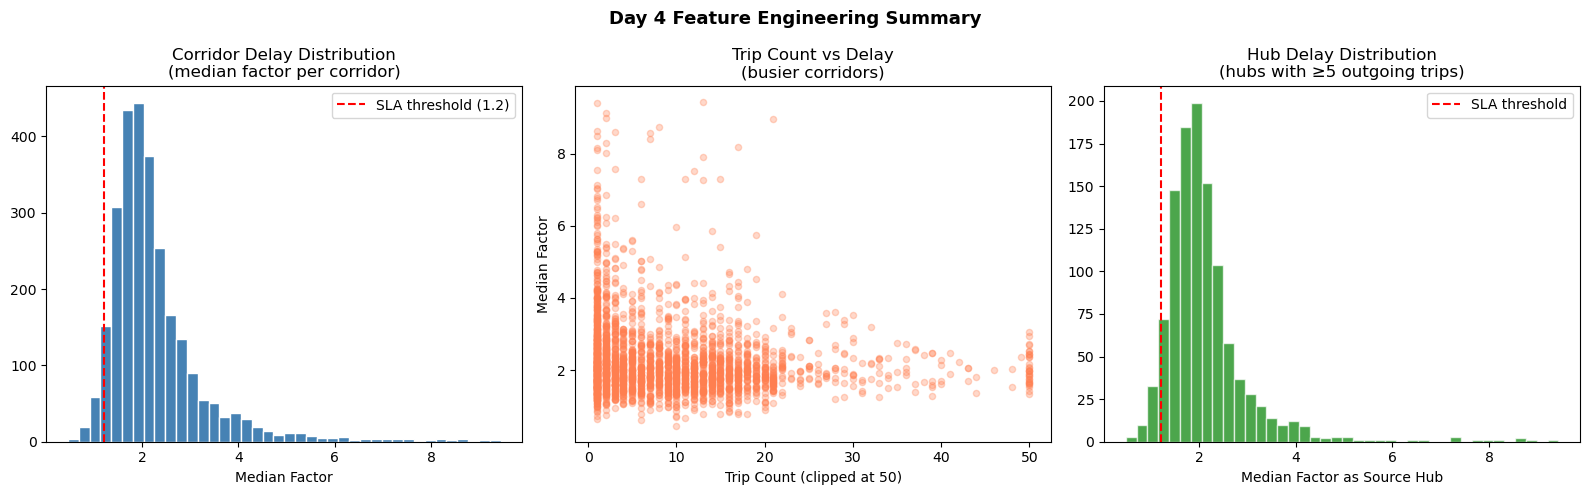

Saved: day4_feature_summary.png


In [69]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribution of corridor median factors
axes[0].hist(corridor_stats['corridor_median_factor'], bins=40,
             color='steelblue', edgecolor='white')
axes[0].axvline(1.2, color='red', linestyle='--', label='SLA threshold (1.2)')
axes[0].set_title('Corridor Delay Distribution\n(median factor per corridor)')
axes[0].set_xlabel('Median Factor')
axes[0].legend()

# 2. Trip count vs delay (do busier corridors delay more?)
axes[1].scatter(
    corridor_stats['corridor_trip_count'].clip(upper=50),
    corridor_stats['corridor_median_factor'],
    alpha=0.3, color='coral', s=20
)
axes[1].set_title('Trip Count vs Delay\n(busier corridors)')
axes[1].set_xlabel('Trip Count (clipped at 50)')
axes[1].set_ylabel('Median Factor')

# 3. Hub out delay distribution
axes[2].hist(hub_stats[hub_stats['hub_out_trip_count'] >= 5]['hub_out_median_factor'],
             bins=40, color='green', edgecolor='white', alpha=0.7)
axes[2].axvline(1.2, color='red', linestyle='--', label='SLA threshold')
axes[2].set_title('Hub Delay Distribution\n(hubs with ≥5 outgoing trips)')
axes[2].set_xlabel('Median Factor as Source Hub')
axes[2].legend()

plt.suptitle('Day 4 Feature Engineering Summary', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('day4_feature_summary.png', dpi=150)
plt.show()
print('Saved: day4_feature_summary.png')

# What You'll Have at End of Day 4

legs_features.csv     → your main dataset, one row per truck leg
                         with ~45 columns including all engineered features

hub_stats.csv         → 1,655 hubs with their delay statistics
                         becomes GRAPH NODES on Day 5

corridor_stats.csv    → 2,767 corridors with their delay statistics
                         becomes GRAPH EDGES on Day 5

chronic_delay_corridors.csv → worst corridors for strategy memo